# Tutorial 2: Evaluating LLMs on MMLU

Welcome to the second tutorial in our AI Safety Evaluations course.

Benchmark evaluation is a core skill in applied ML, but the statistical side is often
treated as an afterthought — a single accuracy number gets reported, and model differences
are treated as real without checking whether they could arise from chance alone.
In this tutorial you will get hands-on experience running evaluations with the inspect_ai
library and applying basic statistical methods to interpret the results rigorously.

**What you'll learn:**

- Load and prepare a benchmark dataset
- Compute confidence intervals for accuracy
- Compare models statistically
- Perform power analysis to plan evaluation size

**By the end:** **You'll have a statistically rigorous evaluation pipeline that can tell you not just how accurate a model is, but whether observed differences between models are real.**

## 1. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from string import ascii_uppercase
from typing import Tuple, List

from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample, hf_dataset, FieldSpec
from inspect_ai.solver import multiple_choice
from inspect_ai.scorer import choice
from inspect_ai.log import EvalLog

In [3]:
# Configure models -- replace with what is available in your environment.
# Examples: 'ollama/llama3.2', 'openai/gpt-4o-mini', 'anthropic/claude-haiku-4-5'

MODEL_A = "ollama/llama2"        # weaker / baseline model
MODEL_B = "ollama/qwen2:latest"  # stronger / comparison model

## 2. Loading MMLU

`hf_dataset` is inspect_ai's loader for Hugging Face datasets. It downloads the data
and wraps each record in a `Sample` -- the standard container that flows through every
inspect_ai pipeline. A `Sample` carries the model input, the expected target, optional
answer choices, and arbitrary metadata you want to keep around.

MMLU stores the correct answer as an integer (0 = A, 1 = B, 2 = C, 3 = D).
The quickest way to load a dataset is with `FieldSpec`, which maps column names to
`Sample` fields. Let's try it first and see what we get.

In [4]:
dataset_raw = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=FieldSpec(
        input="question",
        target="answer",           # raw MMLU answer is an integer index 0-3
        metadata=["choices", "subject"]
    ),
    cached=True
)

sample = dataset_raw[0]
print("input   :", sample.input[:80], "...")
print("target  :", sample.target,  "  <- integer index, not a letter!")
print("choices :", sample.metadata.get("choices"))

input   : Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over ...
target  : 1   <- integer index, not a letter!
choices : ['0', '4', '2', '6']


The `target` came out as an integer -- but inspect_ai's `multiple_choice()` solver
and `choice()` scorer expect it to be a letter (`"A"`, `"B"`, `"C"`, or `"D"`).
When the automatic mapping isn't enough, inspect_ai lets you pass a
**record-to-sample function** that receives the full raw record and returns a `Sample`
you construct yourself.

In [5]:
def record_to_sample(record: dict) -> Sample:
    """
    Convert a raw MMLU record to an inspect_ai Sample.

    MMLU stores the correct answer as an integer index (0=A, 1=B, 2=C, 3=D).
    We convert it to the corresponding uppercase letter so it matches the
    format expected by the choice() scorer.
    """
    answer_idx = int(record["answer"])
    return Sample(
        input=record["question"],
        choices=record["choices"],
        target=ascii_uppercase[answer_idx],   # 0->'A', 1->'B', ...
        metadata=dict(subject=record.get("subject"))
    )


dataset = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=record_to_sample,
    cached=True
)

sample = dataset[0]
print("question :", sample.input[:80], "...")
print("target  :", sample.target, " <- letter now")
print("choices :", sample.choices)

question : Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over ...
target  : B  <- letter now
choices : ['0', '4', '2', '6']


## Assignment 1: Create your working subset

All experiments in this notebook will run on a subject subset small enough to evaluate
quickly. `Dataset.filter()` takes a predicate over `Sample` objects; the `metadata`
field gives access to anything set in `record_to_sample` -- here, the MMLU subject tag.

We define `astronomy_subset` as a reference example. Pick any subject or subjects from the [MMLU subject list](https://huggingface.co/datasets/cais/mmlu#task-descriptions) with at least 50 questions so later analyses are statistically meaningful. Create MY_SUBSET and use it in all subsequent exercises.

In [6]:
# Reference subset used in worked examples
astronomy_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "astronomy"
)
print(f"Astronomy: {len(astronomy_subset)} questions")

MY_SUBJECTS =("college_computer_science", "machine_learning")

MY_SUBSET = dataset.filter(
    lambda s: s.metadata.get("subject") in MY_SUBJECTS
)

print(f"My subset: {len(MY_SUBSET)} questions")


Astronomy: 152 questions
My subset: 212 questions


## 3. Running an evaluation

Every inspect_ai evaluation is described by a `Task`, which bundles three things:

- **dataset** -- the questions
- **solver** -- the chain of steps that produces a model response;
  `multiple_choice()` formats the prompt with lettered options and parses the model's choice
- **scorer** -- the function that grades the response;
  `choice()` checks whether the selected letter matches the target

The `@task` decorator registers the function so inspect_ai can discover it by name
from the CLI or pass it directly to `eval()`.

In [7]:
@task
def mmlu_subset(subset):
    """Minimal MMLU task for any subject subset."""
    return Task(
        dataset=subset,
        solver=[multiple_choice()],
        scorer=choice()
    )

Calling `eval()` runs the task and returns a **list of `EvalLog` objects** -- one per
(task, model) pair. Everything you need is in this object; there is no need to read
log files from disk.

The two most useful attributes:
- `log.results.scores` -- list of scorer results, each with a `metrics` dict
  (`"accuracy"`, `"stderr"`, etc.)
- `log.samples` -- list of `EvalSample` objects with per-question inputs, outputs, and scores

In [11]:
logs: List[EvalLog] = eval(
    mmlu_subset(astronomy_subset),
    model=MODEL_A,
    limit=10        # evaluate only the first 10 questions
)

log = logs[0]      # one task -> one log
print("Status  :", log.status)
print("Model   :", log.eval.model)
print("Accuracy:", log.results.scores[0].metrics["accuracy"].value)

Output()

Status  : success
Model   : ollama/llama2
Accuracy: 0.6


## 4. From `EvalLog` to a DataFrame

## Assignment 2: Implement `log_to_df`

The aggregate accuracy in `log.results` is useful for a quick check, but for the
statistical analyses ahead we need a flat table: **one row per (question, epoch)**
with a numeric `score` column.

`log.samples` is a list of `EvalSample` objects. Each one has:
- `.id` -- question identifier
- `.epoch` -- which run this belongs to (relevant when `epochs > 1`)
- `.scores` -- a dict mapping scorer name to `Score`; the `Score.value` for `choice()` is
  `"C"` (correct) or `"I"` (incorrect)
- `.metadata` -- the metadata dict you set in `record_to_sample`

Implement `log_to_df` so that it converts an `EvalLog` into a DataFrame with columns
`id`, `epoch`, `score` (1/0), and `subject`. The smoke test below will verify the shape.

In [11]:
vars(log)          # покажет все поля и их значения


{'version': 2,
 'status': 'success',
 'eval': EvalSpec(eval_set_id=None, eval_id='WHRJbY7MSCdkVBwjSyuW36', run_id='SiamCjhQvPdjX2AgySHRMu', created='2026-03-26T08:03:35+00:00', task='mmlu_subset', task_id='T4FDBbxHbvfTp5BiexyNXL', task_version=0, task_file=None, task_display_name='mmlu_subset', task_registry_name='mmlu_subset', task_attribs={}, task_args={'subset': 'cais/mmlu'}, task_args_passed={'subset': 'cais/mmlu'}, solver=None, solver_args=None, solver_args_passed={}, tags=None, dataset=EvalDataset(name='cais/mmlu', location='cais/mmlu', samples=152, sample_ids=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10], shuffled=False), sandbox=None, model='ollama/llama2', model_generate_config=GenerateConfig(max_retries=None, timeout=None, attempt_timeout=None, max_connections=None, system_message=None, max_tokens=None, top_p=None, temperature=None, stop_seqs=None, best_of=None, frequency_penalty=None, presence_penalty=None, logit_bias=None, seed=None, top_k=None, num_choices=None, logprobs=None, top_logpr

In [12]:
vars(log.results)  # можно углубляться

{'total_samples': 10,
 'completed_samples': 10,
 'early_stopping': None,
 'scores': [EvalScore(name='choice', scorer='choice', reducer=None, scored_samples=10, unscored_samples=0, params={}, metrics={'accuracy': EvalMetric(name='accuracy', value=0.5, params={}, metadata=None), 'stderr': EvalMetric(name='stderr', value=0.16666666666666666, params={}, metadata=None)}, metadata=None)],
 'metadata': None}

In [13]:
# фильтруем служебные __ методы
[attr for attr in dir(log) if not attr.startswith("_")]

['construct',
 'copy',
 'dict',
 'error',
 'etag',
 'eval',
 'from_orm',
 'invalidated',
 'json',
 'location',
 'log_updates',
 'metadata',
 'model_computed_fields',
 'model_config',
 'model_construct',
 'model_copy',
 'model_dump',
 'model_dump_json',
 'model_extra',
 'model_fields',
 'model_fields_set',
 'model_json_schema',
 'model_parametrized_name',
 'model_post_init',
 'model_rebuild',
 'model_validate',
 'model_validate_json',
 'model_validate_strings',
 'parse_file',
 'parse_obj',
 'parse_raw',
 'plan',
 'populate_scorer_name_for_samples',
 'recompute_tags_and_metadata',
 'reductions',
 'resolve_sample_reductions',
 'results',
 'samples',
 'schema',
 'schema_json',
 'stats',
 'status',
 'tags',
 'update_forward_refs',
 'validate',
 'version']

In [12]:
def log_to_df(log: EvalLog) -> pd.DataFrame:
    """
    Convert an EvalLog to a DataFrame with one row per (question, epoch).

    Columns:
        id      – question identifier
        epoch   – epoch index (0 if epochs=1)
        score   – 1 if correct, 0 otherwise
        subject – MMLU subject tag from metadata

    The choice() scorer stores the result as "C" (correct) or "I" (incorrect).
    """
    rows = []
    for sample in log.samples:
        # choice() scorer кладёт результат под ключом "choice"
        score_value = sample.scores["choice"].value  # "C" or "I"
        rows.append({
            "id":      sample.id,
            "epoch":   sample.epoch,
            "score":   1 if score_value == "C" else 0,
            "subject": sample.metadata.get("subject") if sample.metadata else None
        })
    return pd.DataFrame(rows)

# =================================== TESTS ===================================
df_test = log_to_df(log)

assert set(df_test.columns) >= {"id", "epoch", "score", "subject"}
assert df_test["score"].isin([0, 1]).all()
assert len(df_test) == 10

print(df_test.head())
print(f"\nAccuracy: {df_test['score'].mean():.1%}")

   id  epoch  score    subject
0   1      1      1  astronomy
1   2      1      0  astronomy
2   3      1      1  astronomy
3   4      1      0  astronomy
4   5      1      0  astronomy

Accuracy: 60.0%


## 5. Confidence intervals


A single accuracy number carries uncertainty: the eval used a finite set of questions
sampled from a much larger space. The paper (ss2.1, ss3.1) shows how to quantify this
using the CLT standard error.


## Assignment 3: Implement `ci_accuracy_basic` and `ci_accuracy`

**`ci_accuracy_basic(scores, ci)`** -- the simple case where every question is answered
exactly once. `scores` is a plain numpy array of 0s and 1s. Use Eq. 1 from the paper.

**`ci_accuracy(df, ci)`** -- the general case that handles multiple runs per question
(`epochs > 1`). When K runs exist for a question, average their scores first, then
compute the SE across question-level averages. Pooling all K×n individual answers
would undercount variance -- answers to the same question across epochs are correlated.


In [17]:
def ci_accuracy_basic(scores: np.ndarray, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy -- single run per question (K = 1).

    Parameters
    ----------
    scores : 1-D array of per-question binary scores (0 or 1)
    ci     : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    n = len(scores)
    p_hat = np.mean(scores)
    se = np.sqrt(p_hat * (1 - p_hat) / n)
    z = stats.norm.ppf((1 + ci) / 2)   # для 0.95 -> z ≈ 1.96
    return (p_hat - z * se, p_hat, p_hat + z * se)


def ci_accuracy(df: pd.DataFrame, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy, supporting multiple epochs (K >= 1).

    Parameters
    ----------
    df : DataFrame returned by log_to_df, with columns 'id', 'score', 'epoch'
    ci : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    question_means = df.groupby("id")["score"].mean()
    n = len(question_means)
    p_hat = question_means.mean()
    se = question_means.std(ddof=0) / np.sqrt(n)  # ddof=0 чтобы совпадало с basic при K=1
    z = stats.norm.ppf((1 + ci) / 2)
    return (p_hat - z * se, p_hat, p_hat + z * se)

In [18]:
# =================================== TESTS ===================================
def _make_df(ids, scores, epochs=None):
    if epochs is None:
        epochs = [0] * len(ids)
    return pd.DataFrame({"id": ids, "score": scores, "epoch": epochs})

# ci_accuracy_basic
l, m, u = ci_accuracy_basic(np.ones(10))

assert l == 1.0 and u == 1.0, "perfect accuracy: CI should collapse to 1"

l, m, u = ci_accuracy_basic(np.zeros(10))

assert l == 0.0 and u == 0.0, "zero accuracy: CI should collapse to 0"

scores3 = np.array([1, 1, 0, 1, 0], dtype=float)
l, m, u = ci_accuracy_basic(scores3)

assert l < 0.6 < u, f"0.6 not in [{l:.3f}, {u:.3f}]"

np.random.seed(42)
s = np.random.binomial(1, 0.75, 200).astype(float)
l95, _, u95 = ci_accuracy_basic(s, 0.95)
l99, _, u99 = ci_accuracy_basic(s, 0.99)

assert (u99 - l99) > (u95 - l95), "99% CI must be wider than 95%"
assert np.isclose(l95, 0.6819421067148456, atol=10e-2)
assert np.isclose(u95, 0.8080578932851544, atol=10e-2)

# ci_accuracy (K=1 should match basic)
df3 = _make_df([1,2,3,4,5], scores3.tolist())
l_df, _, u_df = ci_accuracy(df3)
l_ar, _, u_ar = ci_accuracy_basic(scores3)

assert np.isclose(l_df, l_ar) and np.isclose(u_df, u_ar), "K=1 must match basic version"

# ci_accuracy (K=3 should give narrower CI on average)
np.random.seed(0)
rows_k1, rows_k3 = [], []
for q in range(30):
    p = np.random.uniform(0.3, 0.9)
    rows_k1.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": 0})
    for e in range(3):
        rows_k3.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": e})

l1, _, u1 = ci_accuracy(pd.DataFrame(rows_k1))
l3, _, u3 = ci_accuracy(pd.DataFrame(rows_k3))
print(f"K=1 width: {u1-l1:.3f}")
print(f"K=3 width: {u3-l3:.3f}  (narrower on average)")
print("\n✓ All tests passed!")

K=1 width: 0.337
K=3 width: 0.223  (narrower on average)

✓ All tests passed!


## 6. Visualising how CIs shrink

Two things make confidence intervals narrower: more questions (larger n) and more
runs per question (larger K). Your task is to visualise those effects.

## Assignment 4.1: Plot CI width vs number of epochs


Output()

Output()

Output()

Output()

Output()

Output()

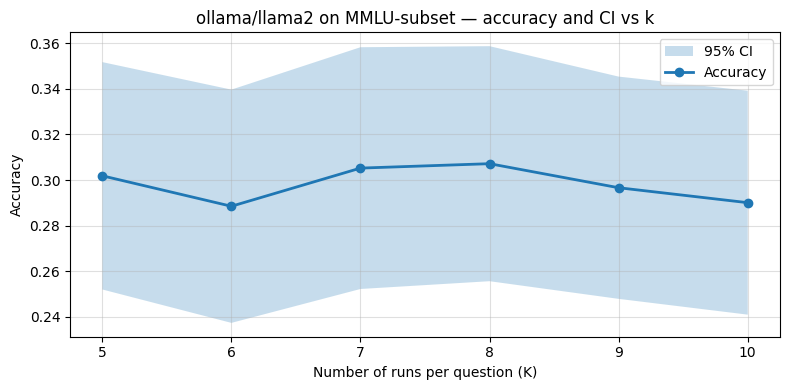

In [19]:
k_values    = [5, 6, 7, 8, 9, 10]
accuracies    = []
ci_lowers     = []
ci_uppers     = []


for k in k_values:
    logs_k = eval(
        mmlu_subset(MY_SUBSET),
        model=MODEL_A,
        epochs=k          # <-- K запусков на каждый вопрос
    )
    df_k = log_to_df(logs_k[0])
    lower, mean, upper = ci_accuracy(df_k)

    accuracies.append(mean)
    ci_lowers.append(lower)
    ci_uppers.append(upper)

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. Look at how fast the band narrows.
   At what point does running another epoch stop being worth it?
2. Does more K change your estimate of the model's accuracy, or just your confidence in it?
3. What does this tell you about how to allocate your evaluation budget?

**Your answer:**

## Assignment 4.2: Compute and plot CI width vs n

For each sample size n in `range(10, len(question_ids)+1, 10)`, slice both DataFrames
to the first n question IDs, compute `ci_accuracy`, and record the CI width.
Then plot width vs n.

Output()

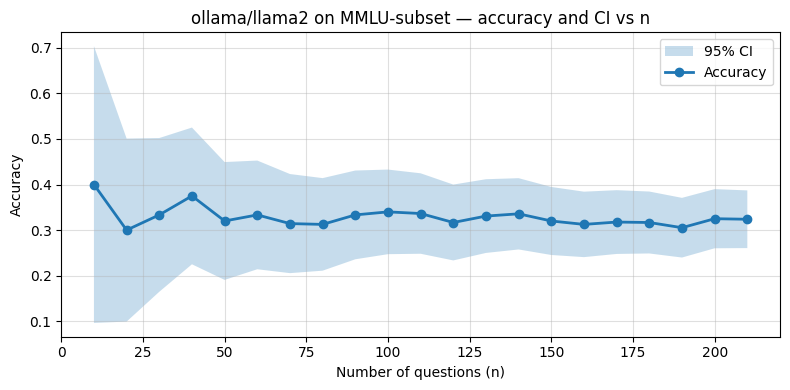

In [20]:
# Один eval-запуск для всего MY_SUBSET (K=1, без limit)
logs_full = eval(
    mmlu_subset(MY_SUBSET),
    model=MODEL_A,
)
df_full = log_to_df(logs_full[0])

# Уникальные ID вопросов в том порядке, как они встречаются
question_ids  = df_full["id"].unique()
dataset_sizes = range(10, len(question_ids) + 1, 10)
accuracies    = []
ci_lowers     = []
ci_uppers     = []

for n in dataset_sizes:
    ids_slice = question_ids[:n]                          # первые n вопросов
    df_slice  = df_full[df_full["id"].isin(ids_slice)]   # фильтруем df
    lower, mean, upper = ci_accuracy(df_slice)

    accuracies.append(mean)
    ci_lowers.append(lower)
    ci_uppers.append(upper)

plt.figure(figsize=(8, 4))
plt.fill_between(dataset_sizes, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(dataset_sizes, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of questions (n)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs n")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. At what n does the accuracy line start to feel stable?
2. Compare that number to the size of `MY_SUBSET` — are you in the reliable region?
3. Compare this curve to the one in 4.1. What is the difference in what K and n actually buy you?

**Your answer:**

Output()

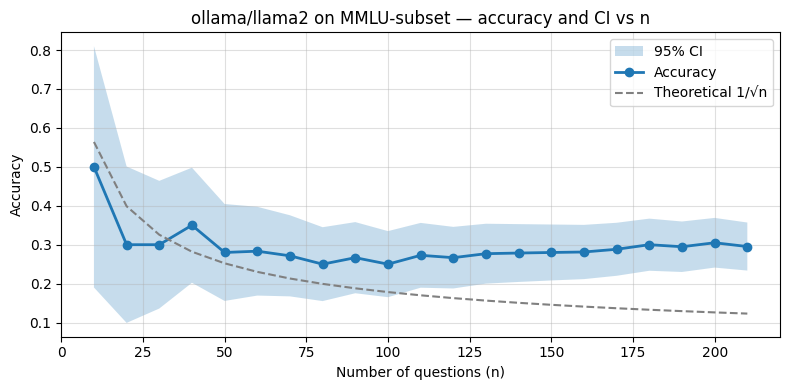

In [21]:
# Один eval-запуск для всего MY_SUBSET (K=1, без limit)
logs_full = eval(
    mmlu_subset(MY_SUBSET),
    model=MODEL_A,
)
df_full = log_to_df(logs_full[0])

# Уникальные ID вопросов в том порядке, как они встречаются
question_ids  = df_full["id"].unique()
dataset_sizes = range(10, len(question_ids) + 1, 10)
accuracies    = []
ci_lowers     = []
ci_uppers     = []

for n in dataset_sizes:
    ids_slice = question_ids[:n]                          # первые n вопросов
    df_slice  = df_full[df_full["id"].isin(ids_slice)]   # фильтруем df
    lower, mean, upper = ci_accuracy(df_slice)

    accuracies.append(mean)
    ci_lowers.append(lower)
    ci_uppers.append(upper)

# Теоретическая ширина CI: 2 * z * sqrt(p*(1-p)/n)
p_hat = df_full["score"].mean()
z = stats.norm.ppf(0.975)
theoretical = [2 * z * np.sqrt(p_hat * (1 - p_hat) / n) for n in dataset_sizes]

plt.figure(figsize=(8, 4))
plt.fill_between(dataset_sizes, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(dataset_sizes, accuracies, "o-", lw=2, label="Accuracy")
plt.plot(dataset_sizes, theoretical, "--", color="gray", label="Theoretical 1/√n")
plt.xlabel("Number of questions (n)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs n")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Comparing two models

Reporting two accuracy numbers side by side doesn't tell you whether the gap is real
or just noise. The paper (§4.2) describes a **paired test**: because both models answer
the same questions, you can compute per-question score differences and test whether
their mean differs significantly from zero. This removes question-difficulty variance
and yields a lower standard error than treating the two runs as independent samples.


## Assignment 5: Compare two models

`run_and_get_scores` and `compare_models_paired` are provided. Complete
`significance_by_paired_ttest` and use it to compare the two models on `MY_SUBSET`.

Implement `significance_by_paired_ttest` and compare MODEL_A and MODEL_B.

In [21]:
def run_and_get_scores(model_name: str, dataset, epochs: int = 1) -> np.ndarray:
    """Run eval and return mean-per-question scores, sorted by question id."""
    print(f"  Running {model_name} ...")
    run_logs = eval(mmlu_subset(dataset), model=model_name, epochs=epochs)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values


def significance_by_paired_ttest(
    scores1: np.ndarray,
    scores2: np.ndarray,
    alpha: float = 0.05,
    two_tailed: bool = True,
) -> Tuple[float, float, bool]:
    """
    Paired t-test between two sets of per-question scores.

    Returns (p_value, mean_difference scores1 - scores2, is_significant).
    """
    assert len(scores1) == len(scores2), "arrays must cover the same questions"
    
    alternative = "two-sided" if two_tailed else "greater"
    
    
    _, p_value = stats.ttest_rel(scores1, scores2, alternative=alternative)
    mean_diff  = float(np.mean(scores1 - scores2))
    
    return p_value, mean_diff, bool(p_value < alpha)


def compare_models_paired(
    model_a: str,
    model_b: str,
    dataset,
    alpha: float = 0.05,
    two_tailed: bool = True,
    epochs_a: int = 1,
    epochs_b: int = 1,
) -> Tuple[float, float, bool]:
    """
    Evaluate both models on the same dataset and run a paired t-test.

    Returns (p_value, mean_difference A - B, is_significant).
    """
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_b, dataset, epochs=epochs_b)
    return significance_by_paired_ttest(scores_a, scores_b, alpha, two_tailed)

In [23]:
# =================================== TESTS ===================================
p, d, sig = significance_by_paired_ttest(np.array([1,2,3]), np.array([1,2,3]))

assert np.isclose(d, 0.0) and not sig

p, d, sig = significance_by_paired_ttest(
    np.array([1,1,1,1,1]), np.array([0,0,0,0,0]), two_tailed=False
)

assert sig and d > 0

print("All tests passed!")

All tests passed!


/home/sai/.conda/envs/inspect_ai_313/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


In [26]:
p_value, mean_diff, is_significant = compare_models_paired(
    MODEL_A, MODEL_B, MY_SUBSET
)

print(f"Model A ({MODEL_A}) accuracy: {run_and_get_scores(MODEL_A, MY_SUBSET).mean():.1%}")
print(f"Model B ({MODEL_B}) accuracy: {run_and_get_scores(MODEL_B, MY_SUBSET).mean():.1%}")
print(f"Mean difference (A - B):      {mean_diff:+.3f}")
print(f"p-value:                       {p_value:.4f}")
print(f"Significant at α=0.05:         {is_significant}")

Output()

  Running ollama/llama2 ...


  Running ollama/qwen2:latest ...


Output()

  Running ollama/llama2 ...


Output()

Model A (ollama/llama2) accuracy: 32.1%
  Running ollama/qwen2:latest ...


Output()

Model B (ollama/qwen2:latest) accuracy: 51.4%
Mean difference (A - B):      -0.212
p-value:                       0.0000
Significant at α=0.05:         True


---
1. Write down the p-value and the mean difference you got.
2. Is the gap significant? Is it large enough to matter in practice?
3. What would change your conclusion: more questions, a different subject, or a different model pair?

**Your answer:**

```
Model A (ollama/llama2) accuracy: 32.1%
Model B (ollama/qwen2:latest) accuracy: 51.4%
Mean difference (A - B):      -0.212
p-value:                       0.0000
Significant at α=0.05:         True
```

!!!! сравнить одинаковые модели чтобы увидеть разницу в Р!!!!!!

## 8. Interval estimation of the accuracy difference

In Assignment 5 you got a yes/no significance decision. Here you will estimate the size of the gap and its uncertainty: a confidence interval on the difference gives both pieces of information at once.

## Assignment 6: Estimate the accuracy gap

Implement `ci_accuracy_for_difference` to compute a 95% CI on the per-question score differences.

Compute and report the confidence interval on MODEL_A − MODEL_B.


In [23]:
def ci_accuracy_for_difference(
    scores1: np.ndarray,
    scores2: np.ndarray,
    ci: float = 0.95,
) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval on the mean per-question score difference
    (scores1 - scores2).

    Returns (lower_bound, mean_difference, upper_bound).
    """
    assert len(scores1) == len(scores2), "arrays must cover the same questions"

    diffs = scores1 - scores2          # per-question разности
    n     = len(diffs)
    mean  = np.mean(diffs)
    se    = np.std(diffs, ddof=0) / np.sqrt(n)
    z     = stats.norm.ppf((1 + ci) / 2)

    return (mean - z * se, mean, mean + z * se)

def run_and_get_scores(model_name: str, dataset, epochs: int = 1) -> np.ndarray:
    """Run eval and return mean-per-question scores, sorted by question id."""
    print(f"  Running {model_name} ...")
    run_logs = eval(mmlu_subset(dataset), model=model_name, epochs=epochs)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values


# (MODEL_B, MY_SUBSET)    
scores_a = run_and_get_scores(MODEL_A, MY_SUBSET, epochs=1)
scores_b = run_and_get_scores(MODEL_B, MY_SUBSET, epochs=1)


Output()

  Running ollama/llama2 ...


  Running ollama/qwen2:latest ...


Output()

In [31]:
lower, diff, upper = ci_accuracy_for_difference(scores_a, scores_b)

print(f"Mean difference (A - B): {diff:+.3f}")
print(f"95% CI: [{lower:+.3f}, {upper:+.3f}]")
print()
if upper < 0:
    print("→ Весь CI ниже нуля: MODEL_B значимо лучше во всём диапазоне")
elif lower > 0:
    print("→ Весь CI выше нуля: MODEL_A значимо лучше во всём диапазоне")
else:
    print("→ CI пересекает ноль: разница статистически незначима")

Mean difference (A - B): -0.236
95% CI: [-0.325, -0.147]

→ Весь CI ниже нуля: MODEL_B значимо лучше во всём диапазоне


---
1. Write down the interval. Does it contain zero?
2. How does this relate to the significance test in Assignment 5 — do they tell the same story?
3. Which result is more informative — the p-value or the interval? Why?

**Your answer:**

## 9. Power analysis

Before running an expensive evaluation, it is worth asking: how many questions do we
need to detect a meaningful difference with adequate statistical power?
The paper (§5) derives the minimum detectable effect as a function of sample size n,
question-level variance ω², and within-model variance σ².

## Assignment 7: 'Estimate variance components'

Implement `estimate_variance_components` and report the MDE for `MY_SUBSET` at α = 0.05, power = 80%.

In [8]:
def estimate_variance_components(
    logs_a: List[EvalLog],
    logs_b: List[EvalLog],
) -> dict:
    """
    Estimate omega2, sigma2_a, sigma2_b from two EvalLog objects (see ss5 of the paper).

    Both logs must cover the same set of questions. Use epochs >= 2 so that
    within-question variance can be estimated.

    Returns dict with keys 'omega2', 'sigma2_a', 'sigma2_b'.
    """

    # YOUR CODE HERE

    df_a = log_to_df(logs_a[0])
    df_b = log_to_df(logs_b[0])

    ka = df_a["epoch"].nunique()
    kb = df_b["epoch"].nunique()

    # Per-question means (усредняем по эпохам)
    means_a = df_a.groupby("id")["score"].mean()
    means_b = df_b.groupby("id")["score"].mean()

    # Работаем только с общими вопросами
    common_ids = means_a.index.intersection(means_b.index)
    means_a = means_a.loc[common_ids]
    means_b = means_b.loc[common_ids]

    # sigma2: среднее по вопросам дисперсий скоров по эпохам
    sigma2_a = df_a.groupby("id")["score"].var(ddof=0).loc[common_ids].mean()
    sigma2_b = df_b.groupby("id")["score"].var(ddof=0).loc[common_ids].mean()

    # omega2: дисперсия разностей минус вклад шума моделей
    d_hat  = means_a - means_b
    omega2 = float(np.var(d_hat.values, ddof=0) - sigma2_a / ka - sigma2_b / kb)
    omega2 = max(omega2, 0.0)   # clamp: дисперсия не может быть отрицательной

    return {
        "omega2":   omega2,
        "sigma2_a": float(sigma2_a),
        "sigma2_b": float(sigma2_b),
    }


def minimum_detectable_effect(
    n: int,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> float:
    """MDE for a paired model comparison (Eq. 10 in the paper)."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    return float((z_alpha + z_beta) * np.sqrt(
        (omega2 + sigma2_a / ka + sigma2_b / kb) / n
    ))

In [13]:
print("Running pilot evals ...")
logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2, limit=15)
logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=2, limit=15)

params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")

mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")

Output()

Running pilot evals ...


Output()

omega2  = 0.2039
sigma2_A = 0.0667
sigma2_B = 0.0500

With n=212 questions -> MDE = 10.9%
(smallest gap detectable at 80% power, alpha=0.05)


In [14]:
# epochs >= 2 обязательно — иначе sigma2 нельзя оценить внутри вопроса
logs_a2 = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=3)
logs_b2 = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=3)

components = estimate_variance_components(logs_a2, logs_b2)
print("Variance components:")
print(f"  omega2   (question-level): {components['omega2']:.4f}")
print(f"  sigma2_a (model A noise):  {components['sigma2_a']:.4f}")
print(f"  sigma2_b (model B noise):  {components['sigma2_b']:.4f}")

# MDE при текущем размере датасета
n   = len(MY_SUBSET)
mde = minimum_detectable_effect(
    n        = n,
    omega2   = components["omega2"],
    sigma2_a = components["sigma2_a"],
    sigma2_b = components["sigma2_b"],
    ka=3, kb=3,
    alpha=0.05, power=0.80,
)
print(f"\nMDE at n={n}, K=3, α=0.05, power=80%: {mde:.3f}")
print(f"Observed gap: {abs(scores_a.mean() - scores_b.mean()):.3f}")
print(f"Gap {'detectable' if abs(scores_a.mean() - scores_b.mean()) > mde else 'NOT detectable'} ✓")

Output()

Output()

Variance components:
  omega2   (question-level): 0.3268
  sigma2_a (model A noise):  0.0535
  sigma2_b (model B noise):  0.0283

MDE at n=212, K=3, α=0.05, power=80%: 0.114


NameError: name 'scores_a' is not defined

In [15]:
components = {
    "omega2":   0.3268,
    "sigma2_a": 0.0535,
    "sigma2_b": 0.0283,
}

mde = minimum_detectable_effect(
    n        = 212,
    omega2   = components["omega2"],
    sigma2_a = components["sigma2_a"],
    sigma2_b = components["sigma2_b"],
    ka=3, kb=3,
    alpha=0.05, power=0.80,
)
observed_gap = abs(0.321 - 0.514)   # из твоих accuracy выше
print(f"MDE:          {mde:.3f}")
print(f"Observed gap: {observed_gap:.3f}")
print(f"Detectable:   {observed_gap > mde}")

MDE:          0.114
Observed gap: 0.193
Detectable:   True


---
1. What MDE did you get for `MY_SUBSET`? Is that gap practically meaningful?
2. If the MDE is larger than the gap you observed in Assignment 5,
   what does that say about your earlier result?

**Your answer:**

## Assignment 8: Implement `required_sample_size`

`minimum_detectable_effect` computes delta given n. Implement its inverse:
given a target delta, return the minimum n needed. Use the sample-size formula
from ss5 of the paper (Eq. 9). Verify it passes the round-trip check,
then use it to compute how many questions you would need to detect a 5% and a 10%
accuracy gap on `MY_SUBSET`.

In [16]:
# --- Assignment 7 -----------------------------------------------------------
def required_sample_size(
    delta: float,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> int:
    """Minimum number of questions needed to detect `delta` at the given power."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    V       = omega2 + sigma2_a / ka + sigma2_b / kb
    n       = (z_alpha + z_beta) ** 2 * V / delta ** 2
    return int(np.ceil(n))   # округляем вверх — нельзя взять дробное число 


# =================================== TESTS ===================================
n_needed = required_sample_size(delta=0.05, **params)
print(f"Questions needed to detect delta=5%: {n_needed}")

mde_check = minimum_detectable_effect(n=n_needed, **params)

assert abs(mde_check - 0.05) < 0.005, f"Round-trip failed: MDE={mde_check:.3f}"

print("Round-trip check passed!")

Questions needed to detect delta=5%: 1007
Round-trip check passed!


In [18]:
# params из компонентов дисперсии — чтобы не дублировать значения
params = dict(
    omega2   = components["omega2"],    # 0.3268
    sigma2_a = components["sigma2_a"],  # 0.0535
    sigma2_b = components["sigma2_b"],  # 0.0283
    ka=3, kb=3,
    alpha=0.05, power=0.80,
)

# Round-trip тест (уже в ноутбуке)
n_needed  = required_sample_size(delta=0.05, **params)
mde_check = minimum_detectable_effect(n=n_needed, **params)
print(f"Questions needed to detect delta=5%: {n_needed}")
assert abs(mde_check - 0.05) < 0.005, f"Round-trip failed: MDE={mde_check:.3f}"
print("Round-trip check passed!")

# YOUR CODE HERE — отчёт для 5% и 10%
for delta in [0.05, 0.10, 0.15]:
    n = required_sample_size(delta=delta, **params)
    print(f"Detect gap={delta:.0%}:  need n={n:>6} questions  (MY_SUBSET has {len(MY_SUBSET)})")

Questions needed to detect delta=5%: 1112
Round-trip check passed!
Detect gap=5%:  need n=  1112 questions  (MY_SUBSET has 212)
Detect gap=10%:  need n=   278 questions  (MY_SUBSET has 212)
Detect gap=15%:  need n=   124 questions  (MY_SUBSET has 212)


---
1. How many questions do you need to detect a 5% gap? A 10% gap?
2. Does `MY_SUBSET` have enough questions to be a useful benchmark for comparing these two models?

**Your answer:**

## Assignment 9: Compare a model with itself: baseline vs chain-of-thought

The `multiple_choice()` solver we have used so far prompts the model to answer
directly. inspect_ai also provides a `chain_of_thought` that asks the model
to reason step by step before giving its final answer.

Using the paired comparison infrastructure from Section 7, evaluate the same model
twice on the same subset — once with the default solver and once with
`chain_of_thought` — and test whether the difference in accuracy is statistically
significant. Does reasoning help? Is the effect consistent across subjects?

In [ ]:
# YOUR CODE HERE

In [ ]:
from inspect_ai.solver import chain_of_thought

# Два таска — один с direct answer, второй с CoT
@task
def mmlu_direct(subset):
    return Task(
        dataset=subset,
        solver=[multiple_choice()],
        scorer=choice()
    )

@task
def mmlu_cot(subset):
    return Task(
        dataset=subset,
        solver=[multiple_choice(cot=True)],  
        scorer=choice()
    )

# Запускаем оба на одном датасете
print("Running direct solver...")
logs_direct = eval(mmlu_direct(MY_SUBSET), model=MODEL_B)  # берём MODEL_B — он сильнее, CoT эффект заметнее
df_direct   = log_to_df(logs_direct[0])

print("Running chain-of-thought solver...")
logs_cot    = eval(mmlu_cot(MY_SUBSET), model=MODEL_B)
df_cot      = log_to_df(logs_cot[0])

Output()

Running direct solver...


Running chain-of-thought solver...


Output()

In [27]:
# Скоры по вопросам (отсортированы по id для парного теста)
scores_direct = df_direct.groupby("id")["score"].mean().sort_index().values
scores_cot    = df_cot.groupby("id")["score"].mean().sort_index().values

# Paired t-test
p_value, mean_diff, is_significant = significance_by_paired_ttest(
    scores_cot, scores_direct   # CoT - Direct: положительный diff = CoT лучше
)

# CI на разности
lower, diff, upper = ci_accuracy_for_difference(scores_cot, scores_direct)

print(f"Direct accuracy:        {scores_direct.mean():.1%}")
print(f"Chain-of-thought:       {scores_cot.mean():.1%}")
print(f"Mean difference (CoT - Direct): {mean_diff:+.3f}")
print(f"95% CI:  [{lower:+.3f}, {upper:+.3f}]")
print(f"p-value: {p_value:.4f}")
print(f"Significant at α=0.05:  {is_significant}")
print()
if is_significant:
    direction = "помогает" if mean_diff > 0 else "вредит"
    print(f"→ Chain-of-thought {direction} (p={p_value:.4f})")
else:
    print("→ Разница статистически незначима — CoT не даёт надёжного улучшения")

Direct accuracy:        53.8%
Chain-of-thought:       14.2%
Mean difference (CoT - Direct): -0.396
95% CI:  [-0.471, -0.322]
p-value: 0.0000
Significant at α=0.05:  True

→ Chain-of-thought вредит (p=0.0000)


In [28]:
# Анализ по subject (если MY_SUBSET содержит несколько тем)
df_direct["solver"] = "direct"
df_cot["solver"]    = "cot"
df_combined         = pd.concat([df_direct, df_cot])

subject_comparison = (
    df_combined
    .groupby(["subject", "solver"])["score"]
    .mean()
    .unstack("solver")
    .assign(cot_improvement=lambda x: x["cot"] - x["direct"])
    .sort_values("cot_improvement", ascending=False)
)
print("\nCoT effect by subject:")
print(subject_comparison.to_string(float_format="{:.3f}".format))


CoT effect by subject:
solver                     cot  direct  cot_improvement
subject                                                
machine_learning         0.089   0.455           -0.366
college_computer_science 0.200   0.630           -0.430


In [29]:
# Посмотри на сырой вывод CoT-модели
sample = logs_cot[0].samples[0]
print("=== INPUT ===")
print(sample.input)
print("\n=== MODEL OUTPUT ===")
print(sample.output.completion)
print("\n=== SCORE ===")
print(sample.scores)

=== INPUT ===
The access matrix approach to protection has the difficulty that

=== MODEL OUTPUT ===
Step 1: Analyze the options:
A. Discusses impracticality in managing a large matrix.
B. Focuses on its limitations with complex requirements.
C. Mentions an issue with decision-making about access based on the matrix.
D. Questions the capability to control modifications of the access matrix.

Step 2: Compare against typical features associated with a matrix solution:
A does address a potential management complexity linked common matrix representations, but might not be exclusive to accessibility matrix.
B points out limitations related to expressing complex requirements across different users.
C points towards computational difficulty or undecidability when determining access rights.
D introduces an issue regarding the control of changes in what could generally refer to modifying protection mechanisms.

Step 3: Decide on a potential answer based on the scenario presented:
Considering th

---
1. Does chain-of-thought help? By how much, and is it significant?
2. Does the result surprise you? What might explain it?
3. Would you expect the same pattern on a different subject?

**Your answer:**

## Bonus assignment: Clustered Standard Errors

Some benchmarks contain groups of related questions — for example, several questions
about the same passage in reading comprehension tasks like DROP or RACE. In such cases
the standard CLT confidence interval is anti-conservative: questions within a group are
correlated, so the effective sample size is smaller than n. Miller (2024) addresses this
with clustered standard errors (§2.2).

Using a reading comprehension benchmark of your choice, implement the clustered
confidence interval (Eq. 4 from the paper) and compare it against the naive CLT interval.
How much wider is the clustered interval? Does the difference depend on the benchmark?
Then compare two models on the same benchmark using the clustered paired standard error
(Eq. 8) — does the conclusion about which model is better change compared to the
naive paired test?

In [ ]:
# YOUR CODE HERE